In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("C:/Users/Thendo/credit-risk-prediction/data/credit_risk_dataset.csv")

data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


the above results tell us that outliers exist within the age and length columns. example: max age = 144 years which is quite impossible.

In [5]:
print(f"Rows before age cleaning: {len(data)}")
data = data[data['person_age'] <= 90]
print(f"Rows after age cleaning: {len(data)}")

data = data[data['person_income'] <= 1_000_000]
print(f"Rows after income cleaning: {len(data)}")

data = data[data['person_emp_length'] <= 60]

Rows before age cleaning: 32581
Rows after age cleaning: 32575
Rows after income cleaning: 32567


In [6]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3044
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
data = data.dropna()
print("Missing values after dropping:", data.isnull().sum().sum())

Missing values after dropping: 0


the dataset describes credit risk amongst youngle people with the average age of individuals being 28 years old. the average income is 66,000 and teh average loan sitting at 9,589 at an interest rate of 11%. default rate is 21.8% which tells us that roughly 1 in 8 borrowers default

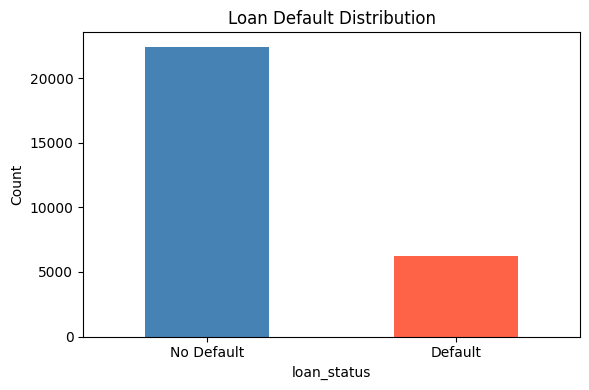

In [8]:
plt.figure(figsize=(6, 4))
data['loan_status'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['No Default', 'Default'], rotation=0)
plt.title('Loan Default Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/target_distribution.png')
plt.show()

Loan Default: no deefualt is approximately 22,500  and defaults are approximately 6,300

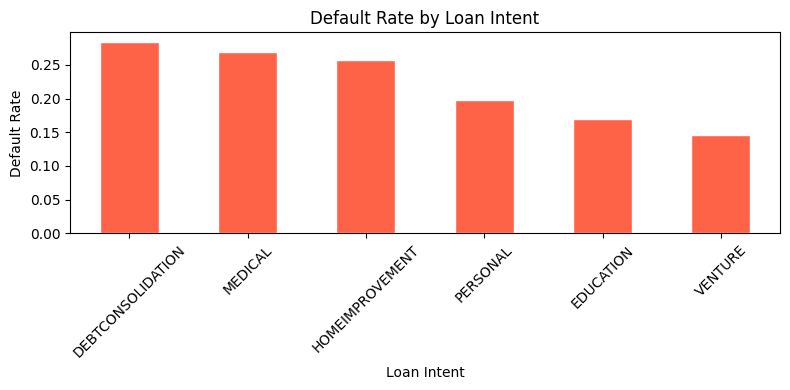

In [9]:
intent_default = data.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
intent_default.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Default Rate by Loan Intent')
plt.ylabel('Default Rate')
plt.xlabel('Loan Intent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/default_by_intent.png')
plt.show()

Debt consolidation (28%) has the highest default rate — people consolidating debt are already financially stressed, so this makes sense
Medical (26%) is second — unexpected medical costs destabilise finances
Home improvement (25%) is surprisingly high
Venture (14%) is actually the lowest — entrepreneurs taking business loans may be more financially disciplined or have assets backing the loan

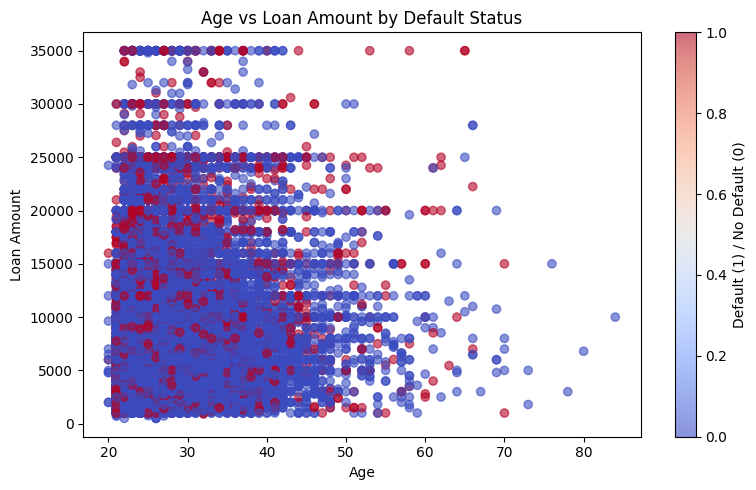

In [10]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    data['person_age'], 
    data['loan_amnt'],
    c=data['loan_status'], 
    cmap='coolwarm', 
    alpha=0.6
)
plt.colorbar(scatter, label='Default (1) / No Default (0)')
plt.title('Age vs Loan Amount by Default Status')
plt.xlabel('Age')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.savefig('../outputs/age_vs_loan.png')
plt.show()

Young borrowers (20-30) dominate the dataset — most applications come from this group
Red dots (defaults) are heavily concentrated in the 20-35 age range — young people taking large loans are the highest risk segment
Older borrowers (50+) are almost entirely blue — very few defaults, and they tend to take smaller loans
Large loans (above R25,000) at young ages = highest risk combination — visible as the dense red cluster top-left

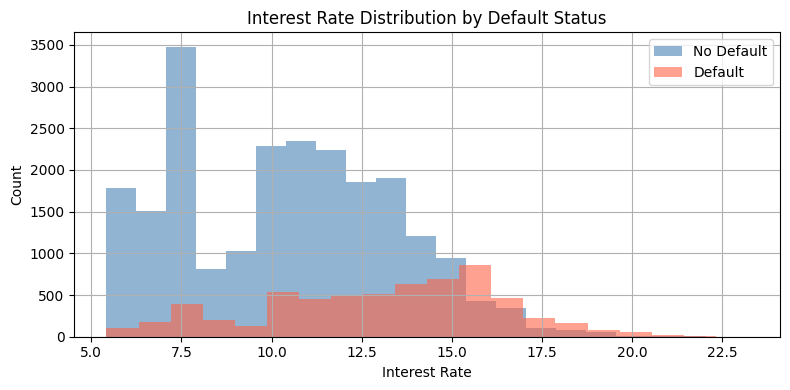

In [12]:
plt.figure(figsize=(8, 4))
data[data['loan_status'] == 0]['loan_int_rate'].hist(bins=20, alpha=0.6, color='steelblue', label='No Default')
data[data['loan_status'] == 1]['loan_int_rate'].hist(bins=20, alpha=0.6, color='tomato', label='Default')
plt.title('Interest Rate Distribution by Default Status')
plt.xlabel('Interest Rate')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/interest_rate_dist.png')
plt.show()

No-default borrowers cluster heavily around 7-8% interest rates while defaulters spread toward 12-20%. This confirms interest rate is a strong signal and lenders charging higher rates are already sensing risk, and that risk materialises into actual defaults.

In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in data.select_dtypes(include='object'):
    data[col] = encoder.fit_transform(data[col])

C:\Users\Thendo\AppData\Local\Temp\ipykernel_6752\831599559.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object'):


In [14]:
X = data.drop(columns=['loan_status'])
y = data['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nTarget balance in training set:\n{y_train.value_counts()}")

Training set: 22900 rows
Test set:     5726 rows

Target balance in training set:
loan_status
0    17939
1     4961
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled. Mean and std normalised to 0 and 1.")

Features scaled. Mean and std normalised to 0 and 1.


In [16]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc
    print(f"\n{'='*45}")
    print(f"{name} | ROC-AUC: {auc:.4f}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    #print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))


Logistic Regression | ROC-AUC: 0.8548
Accuracy: 0.849109325881942

Decision Tree | ROC-AUC: 0.8451
Accuracy: 0.8898009081383165

Random Forest | ROC-AUC: 0.9349
Accuracy: 0.9339853300733496


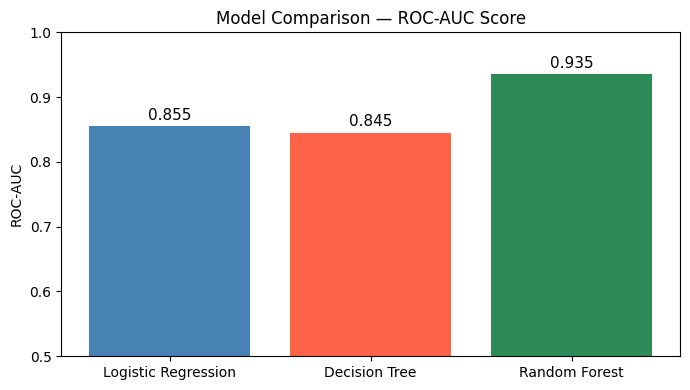

Best performing model: Random Forest (ROC-AUC: 0.9349)


In [17]:
plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), results.values(), color=['steelblue', 'tomato', 'seagreen'])
plt.title('Model Comparison — ROC-AUC Score')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.0)

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

best_model = max(results, key=results.get)
print(f"Best performing model: {best_model} (ROC-AUC: {results[best_model]:.4f})")



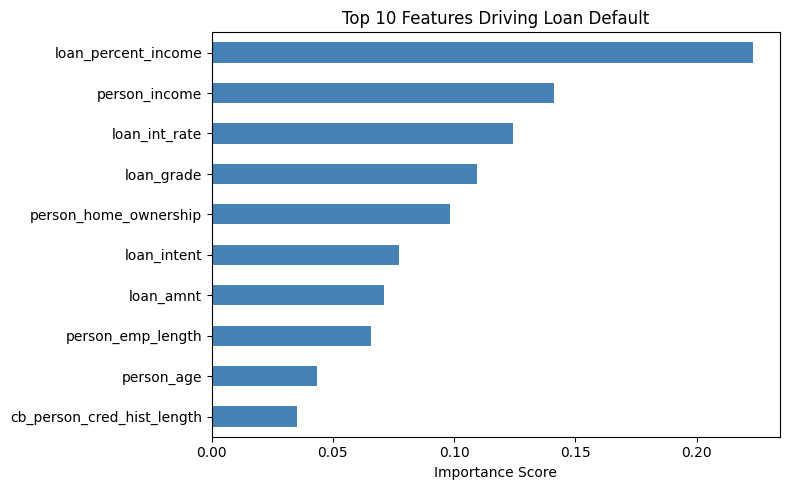

=== TOP PREDICTORS OF DEFAULT ===
  loan_percent_income: 0.2233
  person_income: 0.1411
  loan_int_rate: 0.1244
  loan_grade: 0.1096
  person_home_ownership: 0.0982
  loan_intent: 0.0772
  loan_amnt: 0.0712
  person_emp_length: 0.0656
  person_age: 0.0433
  cb_person_cred_hist_length: 0.0353


In [18]:
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feat_imp.nlargest(10)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Driving Loan Default')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

print("=== TOP PREDICTORS OF DEFAULT ===")
for feat, score in top_features.sort_values(ascending=False).items():
    print(f"  {feat}: {score:.4f}")



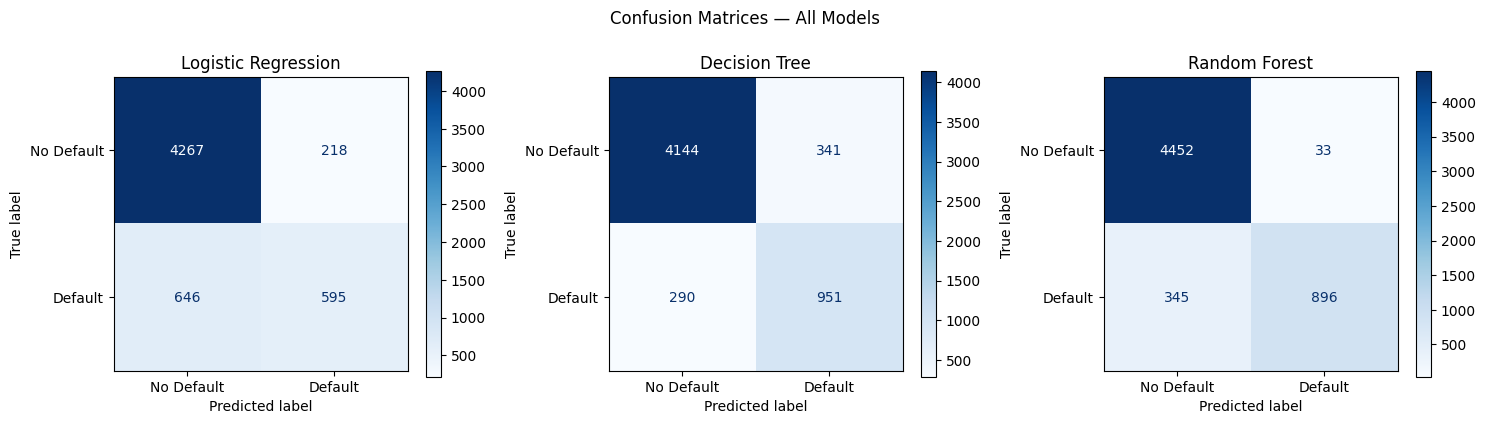

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_scaled, y_test,
        display_labels=['No Default', 'Default'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name)

plt.suptitle('Confusion Matrices — All Models', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png')
plt.show()



In [20]:
importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

importance_df.sort_values(by="importance", ascending=False)

,feature,importance
8,loan_percent_income,0.223282
1,person_income,0.141068
7,loan_int_rate,0.124395
5,loan_grade,0.109619
2,person_home_ownership,0.098250
4,loan_intent,0.077223
6,loan_amnt,0.071239
3,person_emp_length,0.065563
0,person_age,0.043336
10,cb_person_cred_hist_length,0.035340
